# Sàng lọc kích thước, vùng nhìn và backbone rồi chọn mô hình đơn

[Bài 04](04_native_and_resampling.ipynb) giữ DenseNet-121 và chỉ đổi cách lấy điểm ảnh. Native so với Resampled trên Fold 0 trả lời câu hỏi nội suy. Nó không xếp hạng kiến trúc mạng.

Vậy có nên tiếp tục DenseNet hay đổi sang EfficientNet? Trước khi đổi mạng, ta thử hai khả năng ngay trên DenseNet: ảnh đầu vào còn quá nhỏ, hoặc vùng giữa 60% đã bỏ mất dấu hiệu hữu ích. Sau đó mới so backbone ở cùng kích thước đầu vào. Ba câu hỏi cụ thể là:
1. Size 224 so với 288 trên DenseNet-121, vùng `center60`, trần 48 epoch.
2. Vùng nhìn `center60` so với `center72` trên DenseNet-121, size 224, trần 48 epoch.
3. Backbone tại 224 (`densenet121`, `efficientnet_b0`, `efficientnet_b2`) và tại 288 (`densenet121` so với `efficientnet_b2`).

EfficientNet-B2 được đưa vào sàng lọc vì checkpoint ImageNet dùng được, kích thước đầu vào 288px của bộ trọng số đang dùng khớp phép thử tăng kích thước, và kiến trúc nằm trong danh sách được phép chạy. Đó là lý do thử. Lý do giữ một cấu hình phải đọc từ Macro-F1 sau khi xác nhận đủ 3 seed trên 800 cặp phát triển.

Bài này hoàn thành 3 fold OOF, seed `20260917`, cho tám cấu hình; lập shortlist theo quy tắc đã ghi trước khi chạy thêm seed; rồi xác nhận. Blend để sang [Bài 06](06_errors_and_blend.ipynb).


In [1]:
from pathlib import Path
import os
import sys

def find_task_root():
    explicit = os.environ.get('KMD_PROJECT_ROOT')
    if explicit:
        root = Path(explicit).expanduser().resolve()
        if (root / 'src/kmd').is_dir():
            return root
        raise FileNotFoundError('KMD_PROJECT_ROOT phải trỏ đến thư mục KeMaoDanh chứa src/kmd.')
    cwd = Path.cwd().resolve()
    for cand in [cwd, *cwd.parents]:
        if (cand / 'src/kmd').is_dir() and (cand / 'configs').is_dir():
            return cand.resolve()
        if (cand / 'KeMaoDanh/src/kmd').is_dir() and (cand / 'KeMaoDanh/configs').is_dir():
            return (cand / 'KeMaoDanh').resolve()
    raise FileNotFoundError("Không tìm thấy thư mục gốc KeMaoDanh chứa 'src/kmd' và 'configs'.")

TASK_ROOT = find_task_root()
if str(TASK_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(TASK_ROOT / 'src'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from dataclasses import asdict

from kmd.core import split_fold
from kmd.presets import get_preset_config
from kmd.pipeline import prepare_development, start_session
from kmd.decision_flow import run_backbone_screening_suite, run_single_confirmation_suite
from kmd.teaching import resolve_data_roots

KMD_SMOKE = os.environ.get('KMD_SMOKE', '0') == '1'
KMD_RUN_ID = os.environ.get('KMD_RUN_ID', 'reasoning_pilot')
RUN_ID = f"{KMD_RUN_ID}_smoke" if (KMD_SMOKE and not KMD_RUN_ID.endswith('_smoke')) else KMD_RUN_ID

data_root, test_root = resolve_data_roots(TASK_ROOT)
if not data_root.is_dir() or not (data_root / 'pairs.csv').is_file():
    raise FileNotFoundError(
        f"Không tìm thấy thư mục dữ liệu huấn luyện tại '{data_root}'. "
        "Vui lòng thiết lập biến môi trường DATA_ROOT trỏ đến thư mục chứa 'pairs.csv' và 'images/'."
    )

if not torch.cuda.is_available():
    raise RuntimeError(
        "Sàng lọc backbone yêu cầu GPU hỗ trợ CUDA. "
        "Vui lòng dùng máy có GPU hoặc thực hành baseline ở bài 01 và 02."
    )

dev_frame = prepare_development(data_root)
session_dir = start_session(dev_frame, data_root, run_id=RUN_ID)
print(f"Thư mục dự án: {TASK_ROOT}")
print(f"Phiên làm việc: {session_dir.name} (smoke={KMD_SMOKE})")
print(f"Thiết bị tính toán: {torch.cuda.get_device_name(0)}")
print(f"Tổng số cặp phát triển: {len(dev_frame)}")
if KMD_SMOKE:
    raise ValueError('Bài 05 cần KMD_SMOKE=0 để so đủ ngân sách và chọn mô hình. Đặt lại biến rồi chạy từ đầu.')


Thư mục dự án: /home/purin1410-desktop/kmd_full_v5_20260920/repo/KeMaoDanh
Phiên làm việc: lesson_full_v5_20260920 (smoke=False)
Thiết bị tính toán: NVIDIA GeForce RTX 5060 Ti
Tổng số cặp phát triển: 800


## 1. Mốc đối chứng `center60_cap48` và cấu hình `center60` cũ

`center60` ở [Bài 03](03_pretrained_and_finetune.ipynb) dùng DenseNet-121, vùng giữa 60%, size 224, trần 24 epoch, microbatch 24, batch hiệu dụng 24. Nếu lấy đúng cấu hình đó làm mốc cho DenseNet 288 hoặc EfficientNet, ta đổi cùng lúc kích thước (hoặc backbone), trần epoch và cỡ microbatch.

`center60_cap48` giữ nguyên crop, size 224 và DenseNet-121; chỉ đổi trần lên 48 epoch và microbatch 8, batch hiệu dụng vẫn 24. Các ứng viên 288px và EfficientNet trong bài này dùng cùng trần 48, cùng microbatch 8, cùng batch hiệu dụng 24, để giảm nhu cầu VRAM khi tăng kích thước hoặc đổi mạng. Đây là lựa chọn ngân sách của lượt thử, không phải kết luận rằng mọi GPU đều không chạy được microbatch 24.

`center60` vẫn có trong bảng làm mốc tham chiếu của bài 03; các fold đã hoàn tất được tái sử dụng nếu cấu hình và dữ liệu còn khớp. Native được lấy lại làm mốc của bài 04. Hai mốc đó không phải đối chứng đơn biến cho size hay backbone.

Trần 48 đi kèm dừng sớm (patience 6): checkpoint lấy theo validation, có thể dừng trước khi chạm trần. Native vẫn kết thúc đúng 19 epoch cố định; khác biệt ngân sách đó thuộc về từng preset, không gán hết cho tên backbone.


In [2]:
COMPARE_FIELDS = (
    'backbone', 'view', 'size', 'epochs', 'patience', 'warmup',
    'microbatch', 'effective_batch', 'fixed_epochs', 'mode', 'augmentation',
)

def config_row(name):
    cfg = asdict(get_preset_config(name))
    row = {'name': name}
    row.update({k: cfg[k] for k in COMPARE_FIELDS})
    return row

def config_diffs(name_a, name_b):
    a, b = asdict(get_preset_config(name_a)), asdict(get_preset_config(name_b))
    return {k: (a[k], b[k]) for k in COMPARE_FIELDS if a[k] != b[k]}

print('center60 (bài 03) so với center60_cap48 (mốc 48 epoch / micro 8):')
print(config_diffs('center60', 'center60_cap48'))
print('\nHai hàng cấu hình:')
print(pd.DataFrame([config_row('center60'), config_row('center60_cap48')]).to_string(index=False))


center60 (bài 03) so với center60_cap48 (mốc 48 epoch / micro 8):
{'epochs': (24, 48), 'microbatch': (24, 8)}

Hai hàng cấu hình:
          name    backbone     view  size  epochs  patience  warmup  microbatch  effective_batch  fixed_epochs mode augmentation
      center60 densenet121 center60   224      24         6       2          24               24         False full        light
center60_cap48 densenet121 center60   224      48         6       2           8               24         False full        light


## 2. Sáu cấu hình sàng lọc và nguồn các con số

Sáu cấu hình dùng cùng mode `full`, cùng hàm mất mát ảnh, cùng augmentation `light`, cùng warmup 2, cùng patience 6, cùng batch hiệu dụng 24:

| Tên | Backbone | View | Size | Trần epoch | Cặp đối chứng |
| --- | --- | --- | --- | --- | --- |
| `center60_cap48` | DenseNet-121 | center60 | 224 | 48 | mốc chung |
| `dense288` | DenseNet-121 | center60 | 288 | 48 | chỉ đổi size so với mốc |
| `center72` | DenseNet-121 | center72 | 224 | 48 | chỉ đổi view so với mốc |
| `b0_224` | EfficientNet-B0 | center60 | 224 | 48 | chỉ đổi backbone tại 224 |
| `b2_224` | EfficientNet-B2 | center60 | 224 | 48 | chỉ đổi backbone tại 224 |
| `b2` | EfficientNet-B2 | center60 | 288 | 48 | chỉ đổi backbone so với `dense288` |

Nguồn các giá trị, không phải kết quả đã tối ưu lưới:
- 224: size đã dùng từ bài 03 với DenseNet-121 ImageNet.
- 288: kích thước đầu vào theo bộ trọng số EfficientNet-B2 đang dùng; đưa cùng kích thước này sang DenseNet để tách ảnh hưởng của size khỏi backbone.
- 60: heuristic khuôn mặt giữa khung, đã nói ở bài 03; 60% mỗi chiều khoảng 36% diện tích ảnh 512.
- 72: mở rộng vùng giữa từ 60% lên 72% mỗi chiều, vẫn co về 224. Giá trị này có sẵn trong cấu hình thí nghiệm gốc, chưa được chứng minh là tỷ lệ tối ưu.
- Trần 48 và microbatch 8: ngân sách của nhóm thí nghiệm 288, giữ số mẫu mỗi bước cập nhật bằng 24.

`run_backbone_screening_suite` còn hoàn thành `center60` và `native` trên cùng seed để có hai mốc tham chiếu. Shortlist chỉ lấy từ năm challenger: `dense288`, `center72`, `b0_224`, `b2_224`, `b2`.


Ta chờ điều gì ở các phép thử này?
- **Tăng size:** 288px có thể giữ được chi tiết mà 224px làm mất. Tuy nhiên, nó vẫn là ảnh đã nội suy và tốn tính toán hơn; tăng size có thể không giúp.
- **Mở rộng vùng nhìn:** center72 đưa thêm tóc, viền mặt và nền vào ảnh. Nếu dấu hiệu nằm ngoài vùng giữa, mô hình có thêm thông tin; nếu vùng thêm chủ yếu là nhiễu, kết quả có thể giảm. Vì đầu ra vẫn 224px, mở rộng vùng nhìn cũng làm chi tiết khuôn mặt nhỏ hơn.
- **Đổi backbone:** B0 và B2 cho ta hai cấu hình EfficientNet để đối chiếu với DenseNet. Giữ các thiết lập huấn luyện còn lại giống nhau giúp so kết quả của từng cấu hình. Điểm tăng, nếu có, chưa tự giải thích được đặc tính kiến trúc nào tạo ra lợi thế.

Như vậy, thử EfficientNet là một câu hỏi có đối chứng. Ta vẫn cho DenseNet cơ hội ở cả 224px lẫn 288px trước khi chọn mô hình.


Tám cấu hình (sáu sàng lọc và hai mốc tham chiếu):
          name        backbone     view  size  epochs  patience  warmup  microbatch  effective_batch  fixed_epochs mode augmentation
center60_cap48     densenet121 center60   224      48         6       2           8               24         False full        light
      dense288     densenet121 center60   288      48         6       2           8               24         False full        light
      center72     densenet121 center72   224      48         6       2           8               24         False full        light
        b0_224 efficientnet_b0 center60   224      48         6       2           8               24         False full        light
        b2_224 efficientnet_b2 center60   224      48         6       2           8               24         False full        light
            b2 efficientnet_b2 center60   288      48         6       2           8               24         False full        light
      center60    

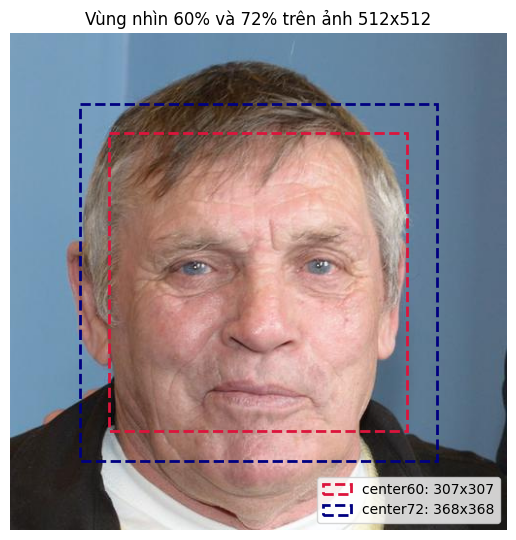

center60: 307x307 px, 36.0% diện tích rồi co về 224.
center72: 368x368 px, 51.8% diện tích rồi co về 224.


In [3]:
SCREEN_ARCHS = ('center60_cap48', 'dense288', 'center72', 'b0_224', 'b2_224', 'b2')
REFERENCE_ARCHS = ('center60', 'native')
CHALLENGERS = ('dense288', 'center72', 'b0_224', 'b2_224', 'b2')
ANCHORS = ('center60', 'center60_cap48', 'native')
PRIMARY_SEED = 20260917
CONFIRM_SEEDS = (20260917, 20260918, 20260919)

df_cfgs = pd.DataFrame([config_row(name) for name in SCREEN_ARCHS + REFERENCE_ARCHS])
print('Tám cấu hình (sáu sàng lọc và hai mốc tham chiếu):')
print(df_cfgs.to_string(index=False))

print('\nCặp đối chứng một yếu tố (chỉ in các trường khác nhau):')
for left, right, label in (
    ('center60_cap48', 'dense288', 'size 224 -> 288'),
    ('center60_cap48', 'center72', 'view 60 -> 72'),
    ('center60_cap48', 'b0_224', 'backbone DenseNet-121 -> EfficientNet-B0 tại 224'),
    ('center60_cap48', 'b2_224', 'backbone DenseNet-121 -> EfficientNet-B2 tại 224'),
    ('dense288', 'b2', 'backbone DenseNet-121 -> EfficientNet-B2 tại 288'),
):
    diffs = config_diffs(left, right)
    print(f'- {label}: {diffs}')

tr_fold0, va_fold0 = split_fold(dev_frame, fold=0)
sample_row = tr_fold0.sort_values('pair_id').iloc[0]
sample_path = data_root / sample_row.image_0
frac60 = float(get_preset_config('center60_cap48').view[6:]) / 100.0
frac72 = float(get_preset_config('center72').view[6:]) / 100.0

with Image.open(sample_path) as img:
    im = img.convert('RGB')
    w, h = im.size

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(im)
for frac, color, label in (
    (frac60, 'crimson', f'center60: {int(w * frac60)}x{int(h * frac60)}'),
    (frac72, 'navy', f'center72: {int(w * frac72)}x{int(h * frac72)}'),
):
    cw, ch = int(w * frac), int(h * frac)
    left, top = (w - cw) // 2, (h - ch) // 2
    ax.add_patch(plt.Rectangle(
        (left, top), cw, ch, linewidth=2, edgecolor=color, facecolor='none',
        linestyle='--', label=label,
    ))
ax.set_title(f'Vùng nhìn 60% và 72% trên ảnh {w}x{h}')
ax.legend(loc='lower right')
ax.axis('off')
plt.tight_layout()
plt.show()
print(f'center60: {int(w * frac60)}x{int(h * frac60)} px, {frac60 * frac60 * 100:.1f}% diện tích rồi co về 224.')
print(f'center72: {int(w * frac72)}x{int(h * frac72)} px, {frac72 * frac72 * 100:.1f}% diện tích rồi co về 224.')


## 3. Sàng lọc seed 20260917 trên 3 fold / 800 cặp

`run_backbone_screening_suite` huấn luyện hoặc hoàn thành đủ 3 fold cho tám cấu hình trên seed `20260917`, ghi `backbone_screening_comparison.csv`, và trả về dự đoán OOF theo tên canonical. Điểm Macro-F1 tính lại từ OOF đã căn ID, không lấy từ một bảng CSV lẻ chưa kiểm tra.

Đọc cả kết quả âm và dương. Một challenger kém mốc vẫn giữ trong bảng. Không lấy lý do đã thử EfficientNet-B2 làm lý do giữ nó.

Hàm sàng lọc hỗ trợ `smoke=True` cho caller khác. Bài này chỉ dùng bảng sàng lọc để lập shortlist khi `KMD_SMOKE=0`.


In [4]:
print(
    "Gọi run_backbone_screening_suite "
    f"(smoke={KMD_SMOKE}). Shortlist chỉ dùng khi KMD_SMOKE=0."
)
table_screen, preds_screen = run_backbone_screening_suite(
    dev_frame, data_root, session_dir, smoke=KMD_SMOKE
)

display_cols = ['model', 'arch', 'seed', 'smoke', 'n', 'macro_f1', 'accuracy', 'auc', 'log_loss', 'errors']
print('\nBảng sàng lọc (3-fold OOF, 800 cặp, seed 20260917):')
print(table_screen[display_cols].to_string(index=False))

screen_primary = table_screen[
    (table_screen['seed'] == PRIMARY_SEED) & (table_screen['smoke'] == KMD_SMOKE)
].set_index('arch')

def f1_of(arch):
    if arch not in screen_primary.index:
        raise KeyError(f"Thiếu hàng sàng lọc cho '{arch}' trên seed {PRIMARY_SEED}.")
    return float(screen_primary.loc[arch, 'macro_f1'])

print('\nChênh lệch Macro-F1 từng cặp đối chứng (challenger trừ mốc, seed 20260917):')
for left, right, label in (
    ('center60_cap48', 'dense288', 'size 224 -> 288'),
    ('center60_cap48', 'center72', 'view 60 -> 72'),
    ('center60_cap48', 'b0_224', 'backbone B0 tại 224'),
    ('center60_cap48', 'b2_224', 'backbone B2 tại 224'),
    ('dense288', 'b2', 'backbone B2 tại 288'),
):
    delta = f1_of(right) - f1_of(left)
    err_left = int(screen_primary.loc[left, 'errors'])
    err_right = int(screen_primary.loc[right, 'errors'])
    print(
        f"- {label}: F1 {f1_of(left):.6f} -> {f1_of(right):.6f} "
        f"(delta={delta:+.6f}); lỗi {err_left} -> {err_right}"
    )

print('\nHai mốc tham chiếu, không dùng để shortlist:')
for arch in REFERENCE_ARCHS:
    print(f"- {arch}: F1={f1_of(arch):.6f}, lỗi={int(screen_primary.loc[arch, 'errors'])}")


Gọi run_backbone_screening_suite (smoke=False). Shortlist chỉ dùng khi KMD_SMOKE=0.


center60_cap48_s20260917_f0: epoch 1/48, loss=0.7095, current_F1=0.5879, best=0.5879


center60_cap48_s20260917_f0: epoch 2/48, loss=0.6766, current_F1=0.6779, best=0.6779


center60_cap48_s20260917_f0: epoch 3/48, loss=0.5659, current_F1=0.8913, best=0.8913


center60_cap48_s20260917_f0: epoch 4/48, loss=0.3879, current_F1=0.9288, best=0.9288


...

native_s20260917_f2: epoch 16/19, loss=0.0156, current_F1=0.9473, best=0.9473


native_s20260917_f2: epoch 17/19, loss=0.0101, current_F1=0.9549, best=0.9549


native_s20260917_f2: epoch 18/19, loss=0.0137, current_F1=0.9549, best=0.9549


native_s20260917_f2: epoch 19/19, loss=0.0302, current_F1=0.9586, best=0.9586



Bảng sàng lọc (3-fold OOF, 800 cặp, seed 20260917):
                   model           arch     seed  smoke   n  macro_f1  accuracy      auc  log_loss  errors
center60_cap48_s20260917 center60_cap48 20260917  False 800  0.968748   0.96875 0.991547  0.168726      25
      dense288_s20260917       dense288 20260917  False 800  0.973750   0.97375 0.993934  0.108034      21
      center72_s20260917       center72 20260917  False 800  0.954995   0.95500 0.987478  0.168515      36
        b0_224_s20260917         b0_224 20260917  False 800  0.961249   0.96125 0.989438  0.155607      31
        b2_224_s20260917         b2_224 20260917  False 800  0.965000   0.96500 0.991387  0.133998      28
            b2_s20260917             b2 20260917  False 800  0.972500   0.97250 0.995419  0.102290      22
      center60_s20260917       center60 20260917  False 800  0.966246   0.96625 0.992063  0.148008      27
        native_s20260917         native 20260917  False 800  0.966247   0.96625 0.994441  0

### Cách đọc từng cặp đối chứng

Mỗi dòng delta vừa in chỉ đổi một yếu tố so với mốc tương ứng. Nếu `dense288` cao hơn `center60_cap48`, size 288 có lợi trên seed này trong ngân sách đang dùng. Nếu thấp hơn hoặc hòa, ghi đúng kết quả đó. Lặp lại cách đọc cho view và backbone.

`center60` (trần 24, microbatch 24) và `native` (4 vùng cắt, 19 epoch) đứng riêng. Chênh lệch của chúng với nhóm cap48 trộn nhiều yếu tố, không gán cho một nguyên nhân.


## 4. Shortlist hai ứng viên rồi xác nhận 3 seed

Một seed có thể thuận lợi riêng cho một cấu hình. Chạy thêm seed cho tất cả ứng viên sẽ tốn thời gian, nên ta lấy hai ứng viên dẫn đầu cùng ba mốc đối chứng để xác nhận. Hai ứng viên là mức giới hạn tính toán của notebook này, không phải một hằng số của phương pháp.

Quy tắc dưới đây được cố định cho lượt chạy mới, trước khi xem kết quả. Đây là cách tái tổ chức thí nghiệm để học và tái chạy; nó không khẳng định mọi lượt thử trong lịch sử đều theo đúng thứ tự này:
1. Trong năm challenger `dense288`, `center72`, `b0_224`, `b2_224`, `b2`, lấy hai tên có Macro-F1 seed `20260917` cao nhất.
2. Nếu hòa F1, chọn theo thứ tự chữ cái.
3. Xác nhận đúng hai tên đó cùng ba mốc `center60`, `center60_cap48`, `native` trên ba seed `20260917`, `20260918`, `20260919`. Seed đầu tái sử dụng bản đã kiểm tra, không train lại nếu artifact còn khớp.
4. Mô hình đơn thắng cuộc là tên có Macro-F1 trung bình cao nhất trên năm cấu hình vừa xác nhận. Hòa thì theo thứ tự chữ cái.
5. Ba seed đo độ nhạy do khởi tạo và thứ tự batch trên cùng 800 cặp, cùng 3 fold. Đây không phải khoảng tin cậy và không phải tập kiểm tra độc lập.
6. Seed nộp bài là `20260917`, chọn trước khi nhìn seed 2 và 3.

`run_single_confirmation_suite` đọc screening đã xác minh, ghi `screening_shortlist.json` trước khi chạy seed thêm, rồi ghi `single_confirmation_comparison.csv` và `single_selection.json`. Khi `KMD_SMOKE=1` hàm trả về bảng rỗng và `None`, không chọn shortlist.


In [5]:
def shortlist_from_screening(table, smoke):
    primary = table[(table['seed'] == PRIMARY_SEED) & (table['smoke'] == smoke)]
    missing = [name for name in CHALLENGERS if name not in set(primary['arch'])]
    if missing:
        raise ValueError(f"Thiếu challenger trên seed {PRIMARY_SEED}: {missing}")
    ranked = []
    for name in CHALLENGERS:
        row = primary.loc[primary['arch'] == name].iloc[0]
        f1 = float(row['macro_f1'])
        if not np.isfinite(f1):
            raise ValueError(f"Macro-F1 không hữu hạn cho {name}.")
        ranked.append((name, f1))
    ranked.sort(key=lambda item: (-item[1], item[0]))
    return [ranked[0][0], ranked[1][0]], ranked

notebook_shortlist, challenger_rank = shortlist_from_screening(table_screen, smoke=KMD_SMOKE)
print('Thứ hạng năm challenger trên seed 20260917 (F1 giảm dần, hòa theo tên):')
for name, f1 in challenger_rank:
    print(f'  {name}: {f1:.6f}')
print(f'Shortlist hai tên: {notebook_shortlist}')

print(
    '\nGọi run_single_confirmation_suite '
    f'(smoke={KMD_SMOKE}). Cần KMD_SMOKE=0 để khóa mô hình đơn.'
)
table_confirm, selection = run_single_confirmation_suite(
    dev_frame, data_root, session_dir, smoke=KMD_SMOKE
)

if KMD_SMOKE or selection is None:
    print('Smoke hoặc artifact chưa đủ: selection=None. Không khóa mô hình đơn.')
    print(table_confirm)
else:
    display_cols = ['model', 'arch', 'seed', 'smoke', 'n', 'macro_f1', 'accuracy', 'auc', 'log_loss', 'errors']
    print('\nBảng xác nhận 3 seed:')
    print(table_confirm[display_cols].to_string(index=False))

    api_shortlist = list(selection['shortlist'])
    print(f"\nShortlist API: {api_shortlist}")
    if api_shortlist != notebook_shortlist:
        raise ValueError(
            f"Shortlist notebook {notebook_shortlist} khác shortlist API {api_shortlist}."
        )

    confirm_ok = table_confirm[
        (table_confirm['smoke'] == False) & (table_confirm['arch'].isin(list(selection['confirmed_methods'])))
    ]
    mean_f1 = {}
    for arch, grp in confirm_ok.groupby('arch'):
        if set(grp['seed']) != set(CONFIRM_SEEDS):
            raise ValueError(f"{arch} thiếu seed xác nhận: {sorted(grp['seed'])}.")
        vals = grp['macro_f1'].to_numpy(dtype=float)
        if not np.isfinite(vals).all():
            raise ValueError(f"Macro-F1 không hữu hạn cho {arch}.")
        mean_f1[arch] = float(vals.mean())

    print('\nMacro-F1 trung bình trên 3 seed (năm cấu hình xác nhận):')
    for arch, value in sorted(mean_f1.items(), key=lambda item: (-item[1], item[0])):
        print(f'  {arch}: {value:.6f}')

    notebook_winner = sorted(mean_f1.items(), key=lambda item: (-item[1], item[0]))[0][0]
    print(f"\nMô hình đơn theo trung bình (hòa theo tên): {notebook_winner}")
    print(f"selection['method']: {selection['method']}")
    if notebook_winner != selection['method']:
        raise ValueError(
            f"Winner notebook '{notebook_winner}' khác selection['method'] '{selection['method']}'."
        )

    print('\nTrường selection đã ghi:')
    for key in (
        'protocol', 'method', 'confirmed_methods', 'shortlist', 'seeds',
        'mean_macro_f1', 'seed_for_submission', 'partition', 'private_used',
    ):
        print(f'  {key}: {selection.get(key)}')
    if selection.get('seed_for_submission') != PRIMARY_SEED:
        raise ValueError('seed_for_submission phải là 20260917, đã chọn trước.')
    if selection.get('private_used') is not False or selection.get('partition') != 'development':
        raise ValueError('Lựa chọn phải nằm trên development, chưa dùng private.')


Thứ hạng năm challenger trên seed 20260917 (F1 giảm dần, hòa theo tên):
  dense288: 0.973750
  b2: 0.972500
  b2_224: 0.965000
  b0_224: 0.961249
  center72: 0.954995
Shortlist hai tên: ['dense288', 'b2']

Gọi run_single_confirmation_suite (smoke=False). Cần KMD_SMOKE=0 để khóa mô hình đơn.


dense288_s20260918_f0: epoch 1/48, loss=0.6855, current_F1=0.6667, best=0.6667


dense288_s20260918_f0: epoch 2/48, loss=0.6592, current_F1=0.7640, best=0.7640


dense288_s20260918_f0: epoch 3/48, loss=0.5471, current_F1=0.8801, best=0.8801


dense288_s20260918_f0: epoch 4/48, loss=0.3925, current_F1=0.9288, best=0.9288


...

native_s20260919_f2: epoch 16/19, loss=0.0834, current_F1=0.9549, best=0.9549


native_s20260919_f2: epoch 17/19, loss=0.1471, current_F1=0.9436, best=0.9436


native_s20260919_f2: epoch 18/19, loss=0.0438, current_F1=0.9436, best=0.9436


native_s20260919_f2: epoch 19/19, loss=0.0067, current_F1=0.9511, best=0.9511



Bảng xác nhận 3 seed:
                   model           arch     seed  smoke   n  macro_f1  accuracy      auc  log_loss  errors
      dense288_s20260917       dense288 20260917  False 800  0.973750   0.97375 0.993934  0.108034      21
      dense288_s20260918       dense288 20260918  False 800  0.962494   0.96250 0.990134  0.158382      30
      dense288_s20260919       dense288 20260919  False 800  0.968749   0.96875 0.990216  0.173065      25
            b2_s20260917             b2 20260917  False 800  0.972500   0.97250 0.995419  0.102290      22
            b2_s20260918             b2 20260918  False 800  0.981250   0.98125 0.994938  0.096488      15
            b2_s20260919             b2 20260919  False 800  0.973750   0.97375 0.994819  0.111839      21
      center60_s20260917       center60 20260917  False 800  0.966246   0.96625 0.992063  0.148008      27
      center60_s20260918       center60 20260918  False 800  0.965000   0.96500 0.987084  0.191870      28
      center60

## 5. Mô hình đơn được chọn và câu hỏi tiếp theo

Tên trong `selection['method']` là mô hình đơn thắng theo quy tắc trên. Ba seed cho biết thứ hạng có đảo hay không trên cùng bộ chia; chúng không thay thế 200 cặp holdout hay private.

Chưa blend. Native có thể bổ sung lỗi cho mô hình vừa chọn, nhưng cũng có thể kéo các cặp đang đúng sang sai. [Bài 06](06_errors_and_blend.ipynb) đếm bốn nhóm đó trên OOF seed `20260917`, rồi mới thử trung bình xác suất 50/50 và cổng +0.005 trên ba seed.

Nếu muốn đọc phụ lục A-D trên cùng phiên, chạy chúng trước khi [Bài 07](07_private_and_submission.ipynb) khóa danh sách. Phụ lục C và D giữ EfficientNet-B2 288px như một phép thử cố định, không đổi theo mô hình đơn vừa chọn.
